In [2]:
#import independices to our project 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import EarlyStopping ,ReduceLROnPlateau

%matplotlib inline

In [3]:
data = pd.read_csv('BodyFat - Extended.csv')
data.head(5)

,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,Y,M,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,Y,M,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,Y,M,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,Y,M,26,83.80,1.84,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,Y,M,24,83.58,1.81,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [4]:
data.columns

Index(['BodyFat', 'Original', 'Sex', 'Age', 'Weight', 'Height', 'Neck',
       'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps',
       'Forearm', 'Wrist'],
      dtype='object')

In [5]:
data.shape

(436, 16)

In [6]:
data.dtypes

BodyFat     float64
Original     object
Sex          object
Age           int64
Weight      float64
Height      float64
Neck        float64
Chest       float64
Abdomen     float64
Hip         float64
Thigh       float64
Knee        float64
Ankle       float64
Biceps      float64
Forearm     float64
Wrist       float64
dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BodyFat   436 non-null    float64
 1   Original  436 non-null    object 
 2   Sex       436 non-null    object 
 3   Age       436 non-null    int64  
 4   Weight    436 non-null    float64
 5   Height    436 non-null    float64
 6   Neck      436 non-null    float64
 7   Chest     436 non-null    float64
 8   Abdomen   436 non-null    float64
 9   Hip       436 non-null    float64
 10  Thigh     436 non-null    float64
 11  Knee      436 non-null    float64
 12  Ankle     436 non-null    float64
 13  Biceps    436 non-null    float64
 14  Forearm   436 non-null    float64
 15  Wrist     436 non-null    float64
dtypes: float64(13), int64(1), object(2)
memory usage: 54.6+ KB


In [8]:
data.isnull().sum()

BodyFat     0
Original    0
Sex         0
Age         0
Weight      0
Height      0
Neck        0
Chest       0
Abdomen     0
Hip         0
Thigh       0
Knee        0
Ankle       0
Biceps      0
Forearm     0
Wrist       0
dtype: int64

In [9]:
data.describe()

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,20.249839,34.545872,72.282203,1.734048,35.250917,94.158028,82.816055,98.652294,56.039679,37.365596,22.351835,29.897248,26.482110,17.139908
std,7.502125,15.500099,15.464366,0.098359,3.837908,10.931688,14.652729,6.895034,6.194143,2.768403,1.780513,3.944843,3.155306,1.582291
min,0.000000,1.000000,42.184800,0.750000,26.000000,43.000000,58.000000,82.500000,38.000000,24.700000,18.000000,20.500000,20.000000,13.500000
25%,15.022500,21.000000,59.875200,1.668780,31.500000,85.500000,70.000000,94.000000,51.500000,35.400000,21.000000,26.950000,23.700000,16.000000
50%,20.500000,28.500000,70.815800,1.730000,35.450000,93.050000,82.850000,98.300000,56.000000,37.500000,22.300000,29.800000,26.650000,17.300000
75%,25.410000,46.000000,81.560000,1.800000,38.300000,101.425000,93.225000,102.500000,60.000000,39.000000,23.300000,32.625000,29.200000,18.400000
max,47.500000,81.000000,164.720000,1.970000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [10]:
data['Age'].describe()

count    436.000000
mean      34.545872
std       15.500099
min        1.000000
25%       21.000000
50%       28.500000
75%       46.000000
max       81.000000
Name: Age, dtype: float64

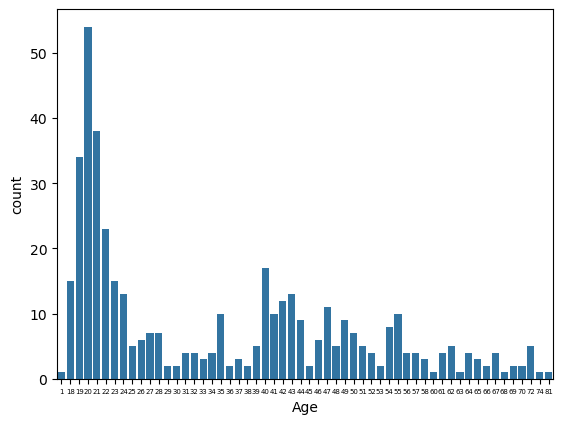

In [11]:
sns.countplot(x='Age',data=data)
plt.xticks(fontsize=5)
plt.show()

# We i want to analyis of Exploratory data analysis 


# Simply we define a function


In [12]:
def describe(df):
    
    variables = []
    dtypes = []
    count = []
    unique = []
    missing = []
    min_ = []
    max_ = []
    
    for item in df.columns:
        variables.append(item)
        dtypes.append(df[item].dtype)
        count.append(len(df[item]))
        unique.append(len(df[item].unique()))
        missing.append(df[item].isna().sum())
        
        if df[item].dtypes == 'float64' or df[item].dtypes == 'int64':
            min_.append(df[item].min())
            max_.append(df[item].max())
        else: 
            min_.append('Str')
            max_.append('Str')
            
    output = pd.DataFrame({
        'variable': variables,
        'dtype': dtypes,
        'count': count,
        'unique': unique,
        'missing values' : missing,
        'Min': min_,
        'Max': max_
    })
    
    return output

# i giving the style to my Analysis ,what ever i done....

In [13]:
Styles = [dict(selector = 'caption',
              props = [('color', 'darkblue'),
                       ('fontsize','bold'),
                       ('text-align', 'center'),
                       ('font-size', '20pt')])]

In [14]:
df_ = describe(data)
df_= df_.style.set_caption('Table 1:OverView of dataset').set_table_styles(Styles)
df_

,variable,dtype,count,unique,missing values,Min,Max
0,BodyFat,float64,436,344,0,0.000000,47.500000
1,Original,object,436,2,0,Str,Str
2,Sex,object,436,2,0,Str,Str
3,Age,int64,436,56,0,1,81
4,Weight,float64,436,261,0,42.184800,164.720000
5,Height,float64,436,76,0,0.750000,1.970000
6,Neck,float64,436,120,0,26.000000,51.200000
7,Chest,float64,436,227,0,43.000000,136.200000
8,Abdomen,float64,436,247,0,58.000000,148.100000
9,Hip,float64,436,181,0,82.500000,147.700000


# Add BMI column 

In [15]:
data['Height'].max()

1.97

In [16]:
height_meter = (data['Height'] *39.37* 0.0254).round(2)
weight_kg = (data['Weight'] * 0.454).round(2)
# weight_kg,height_meter
bmi = (weight_kg/height_meter**2).round()

data1 = pd.DataFrame(bmi)
data1

,0
0,11.0
1,11.0
2,11.0
3,11.0
4,12.0
...,...
431,11.0
432,9.0
433,10.0
434,8.0


In [17]:
data['bmi'] = data1
# data.head(3)
data.insert(0,'Bmi',bmi)

In [18]:
data['Original'].describe()

count     436
unique      2
top         Y
freq      252
Name: Original, dtype: object

In [19]:
data2 = data
data2 = data.drop('Original',axis=1)
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,bmi
0,11.0,12.3,M,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,11.0
1,11.0,6.1,M,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,11.0
2,11.0,25.3,M,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,11.0


In [20]:
data2 = data2.drop('bmi',axis=1)
data2

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,11.0,12.30,M,23,69.9700,1.7200,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,11.0,6.10,M,22,78.5900,1.8400,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,11.0,25.30,M,22,69.8500,1.6800,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,11.0,10.40,M,26,83.8000,1.8400,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,12.0,28.70,M,24,83.5800,1.8100,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,11.0,30.40,F,23,59.8752,1.5621,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
432,9.0,7.47,F,21,48.5352,1.5748,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
433,10.0,11.98,F,20,51.7104,1.5748,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
434,8.0,11.24,F,22,50.8032,1.6510,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


In [21]:
data2['Sex'] = data2['Sex'].replace({'M':1,'F':0})
data2.head(3)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\4101723603.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data2['Sex'] = data2['Sex'].replace({'M':1,'F':0})


,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6


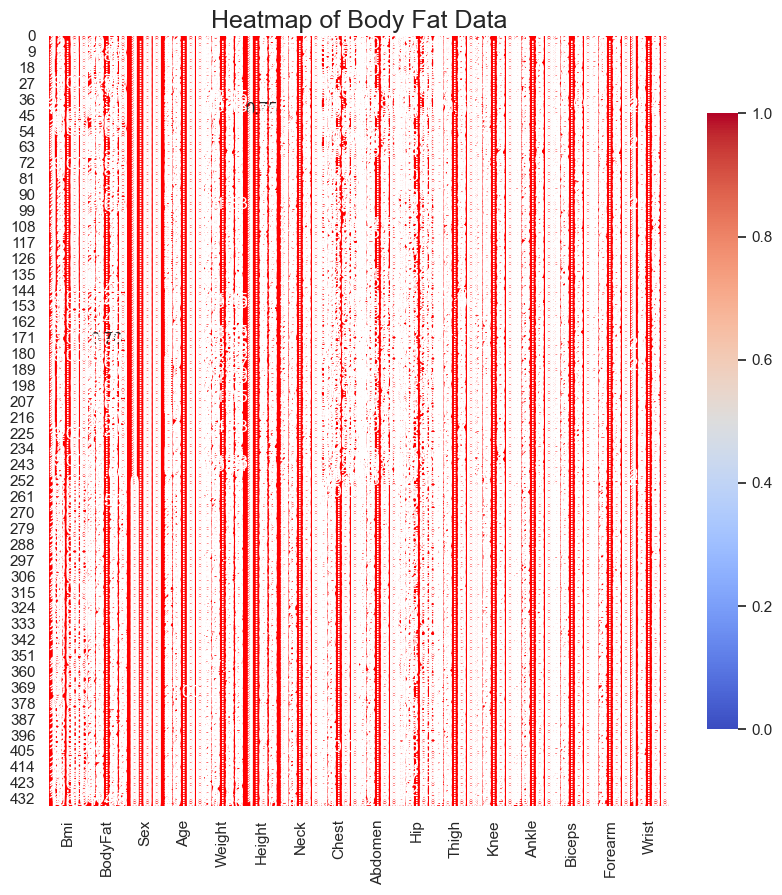

In [22]:
# corr = data.corr('pearson')

sns.set(style='darkgrid')
plt.figure(figsize=(10,10))
heatmap = sns.heatmap(data2, 
                       annot=True,                
                       fmt=".2f",                
                       cmap='coolwarm',          
                       linewidths=.2,            
                       linecolor='red',        
                       cbar_kws={"shrink": .8},
                       vmin=0, vmax=1)  

plt.title('Heatmap of Body Fat Data', fontsize=18)


# Show the heatmap
plt.show()

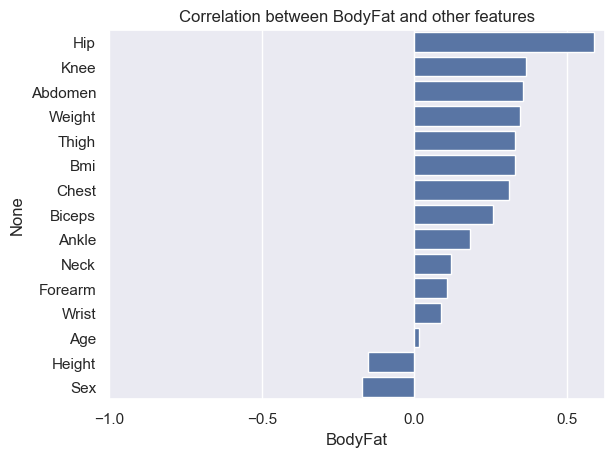

In [23]:
corr = data2.corr()
corr = corr.BodyFat
cr = corr.sort_values(ascending = False)[1:]
sns.barplot(x=cr,y=cr.index)
plt.xticks(np.arange(-1,1,.5))
plt.title('Correlation between BodyFat and other features')
plt.show()

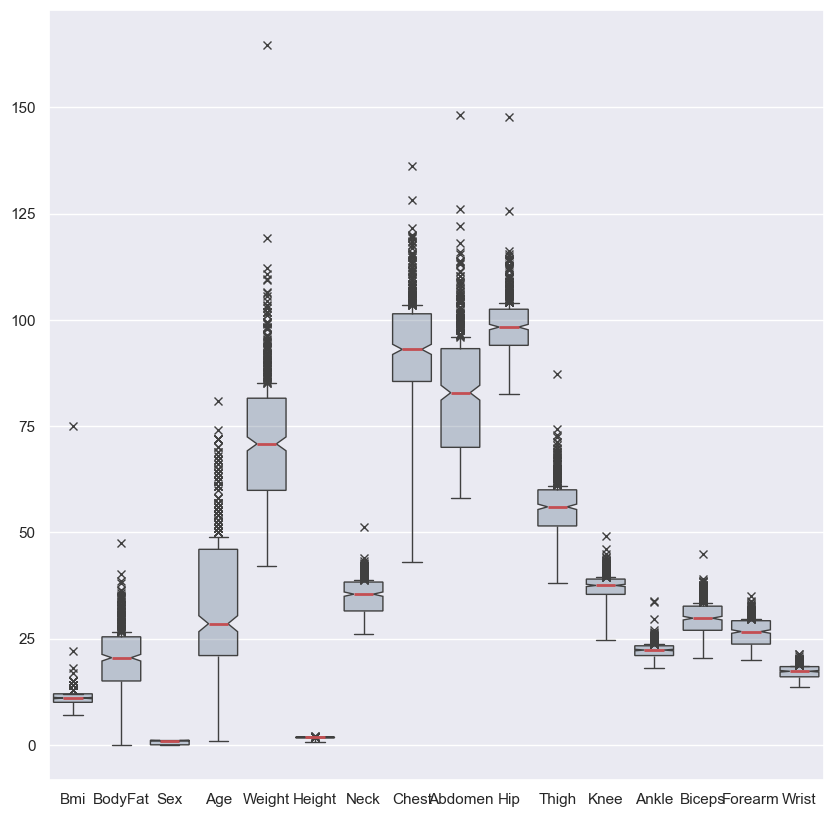

In [24]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data2,notch=True,showcaps=True,flierprops={'marker':'x'},
            boxprops={'facecolor':(.3,.4,.5,.3)},medianprops={'color':'r','linewidth':2},whis=(0,80))
plt.show()

In [25]:
for column in data2:
    plt.figure(figsize=(16,1))
    sns.boxplot(data=data2,x=column,color='lightcoral')

In [26]:
data2 = data2[data2['Bmi']<35]
data2.reset_index()

,index,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,0,11.0,12.30,1,23,69.9700,1.7200,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1,11.0,6.10,1,22,78.5900,1.8400,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,2,11.0,25.30,1,22,69.8500,1.6800,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,3,11.0,10.40,1,26,83.8000,1.8400,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,4,12.0,28.70,1,24,83.5800,1.8100,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,431,11.0,30.40,0,23,59.8752,1.5621,31.3,89.0,71.0,98.5,56.0,36.2,21.0,28.0,24.5,16.3
431,432,9.0,7.47,0,21,48.5352,1.5748,29.5,79.0,62.5,89.0,49.0,33.0,20.0,25.0,22.0,15.5
432,433,10.0,11.98,0,20,51.7104,1.5748,31.5,81.5,61.5,90.0,49.5,32.0,19.5,27.5,22.5,15.0
433,434,8.0,11.24,0,22,50.8032,1.6510,30.5,85.0,64.0,88.0,45.0,32.0,19.5,24.0,21.5,15.0


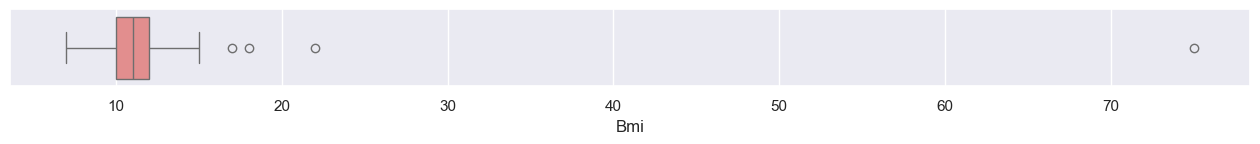

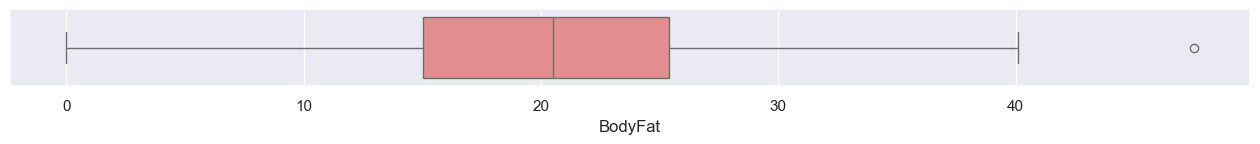

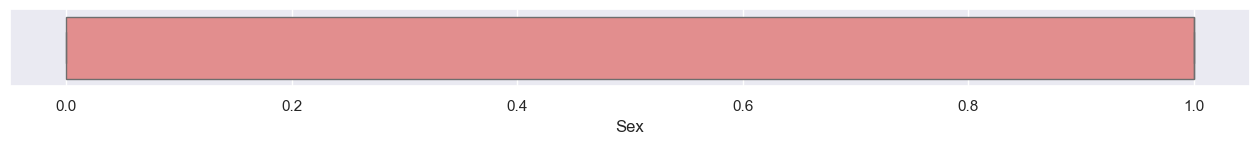

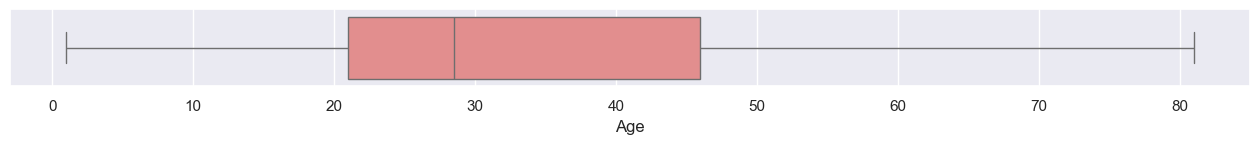

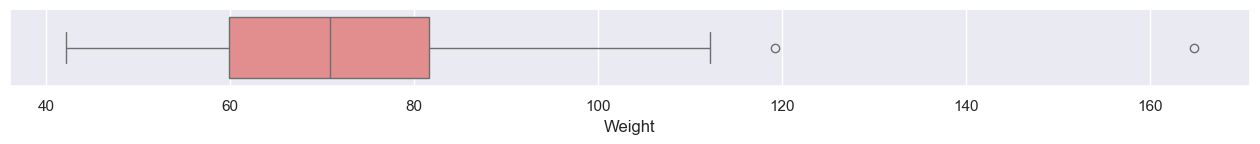

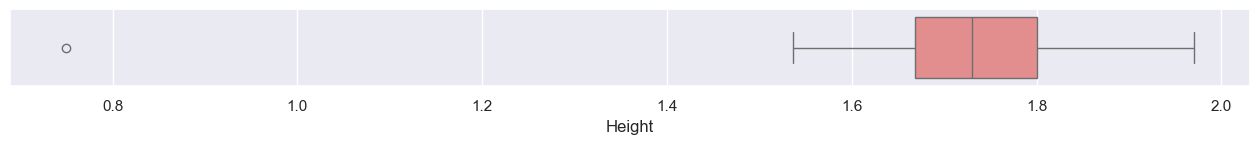

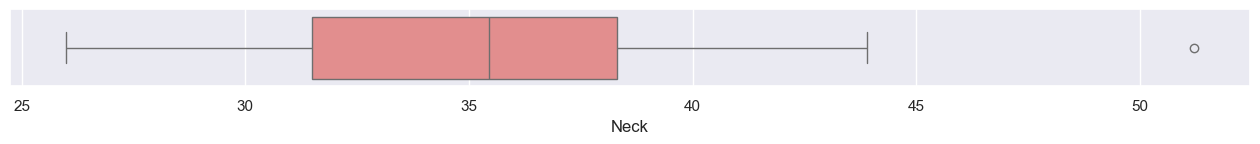

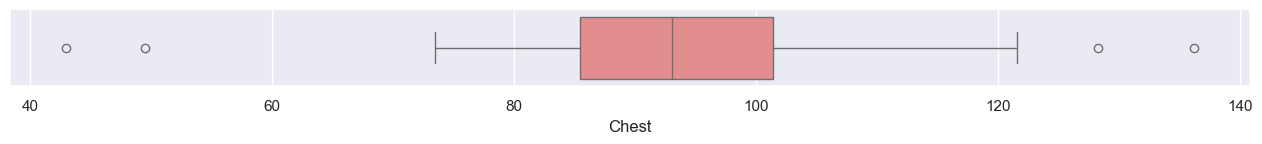

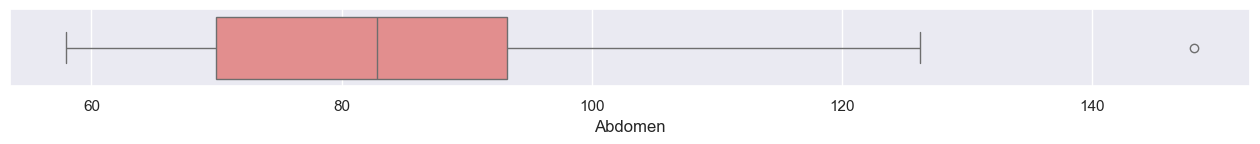

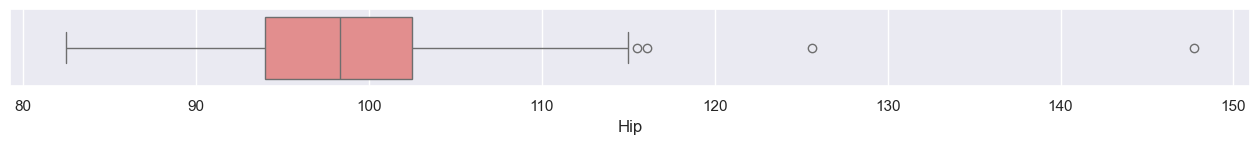

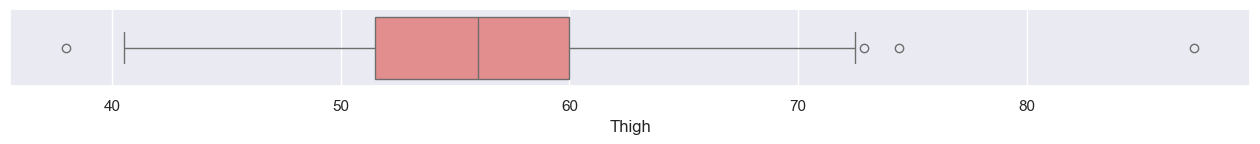

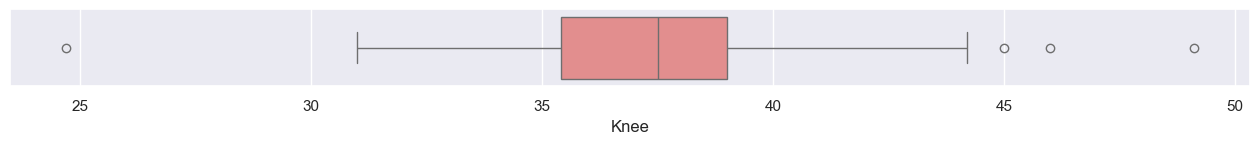

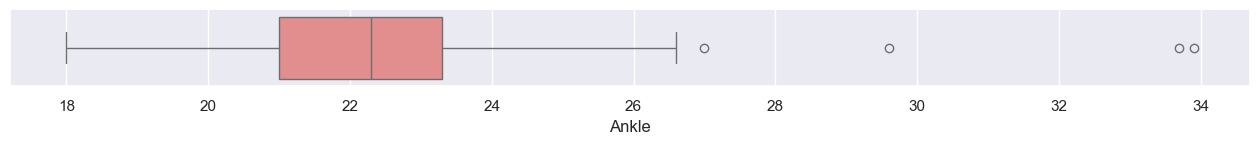

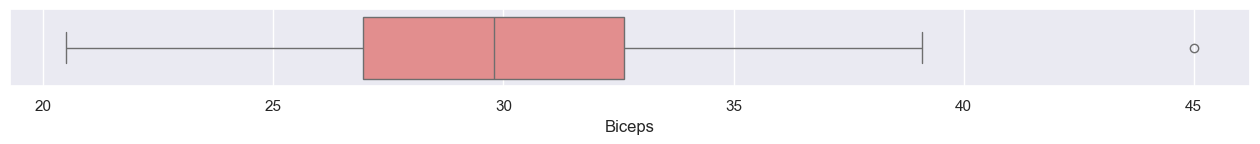

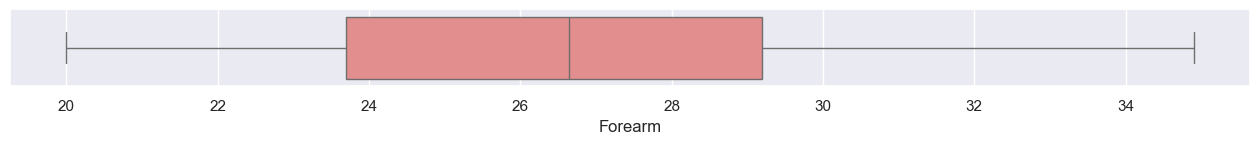

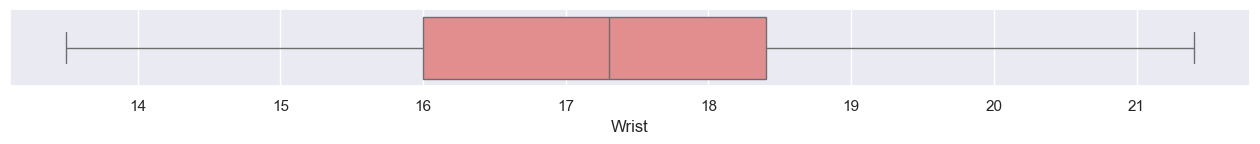

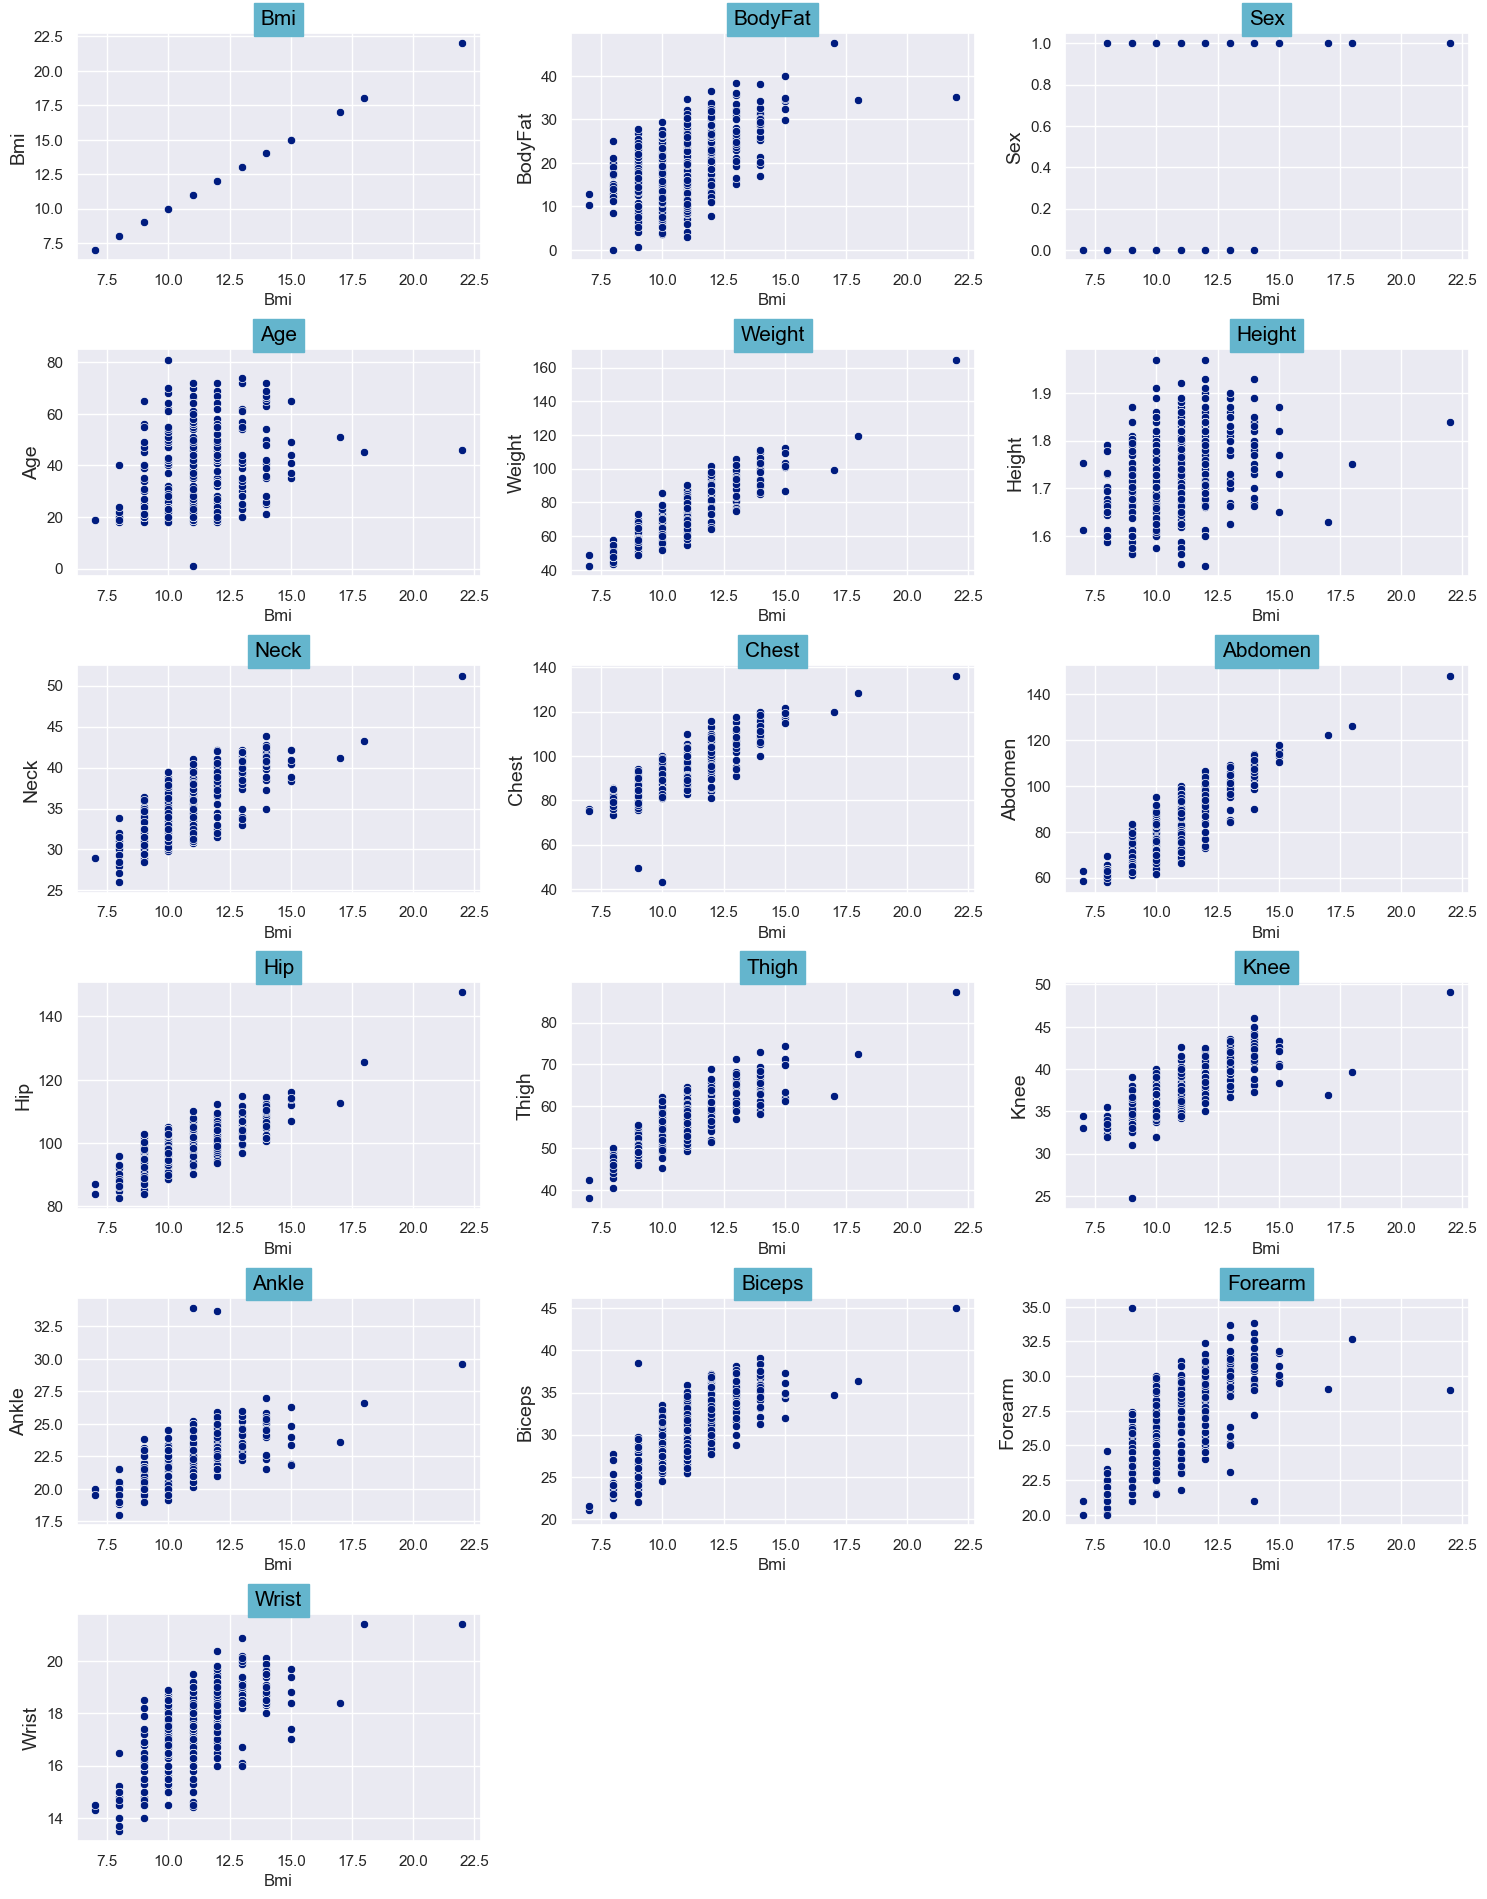

In [27]:
sns.set_palette('dark')
plt.figure(figsize=(15,25))
for idx , i in enumerate (data2):
    plt.subplot(8, 3, idx + 1)
    sns.scatterplot(x =data2['Bmi'], y=data2[i] , data = data2)
    plt.title(i,backgroundcolor='c',color='black',fontsize=15)
    plt.xlabel('Bmi' , size = 12)
    plt.ylabel(i , size = 14)
plt.tight_layout()                     
plt.show()

In [28]:
avg_bodyfat_age = data2.groupby('Age')['BodyFat'].mean().reset_index()
plot = px.line(avg_bodyfat_age, x='Age', y='BodyFat',title = 'Average BodyFat by Age')
plot.show()

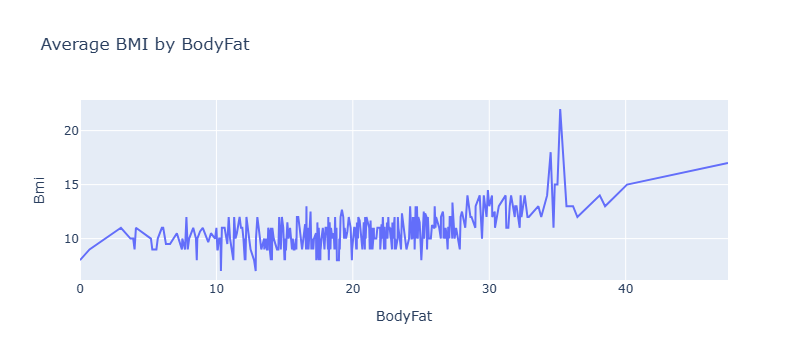

In [29]:
avg_BodyFat_age = data2.groupby('BodyFat')['Bmi'].mean().reset_index()
plot = px.line(avg_BodyFat_age, x='BodyFat', y='Bmi',title = 'Average BMI by BodyFat')
plot.show()

In [30]:
plt.figure(figsize=(20,10), dpi=200)
plt.hist(data2['Bmi'])
plt.xticks(np.arange(15,35,1))
plt.title('Bmi Score',fontsize=19)
plt.xlabel('Bmi', fontsize=17)

plt.axvline(x=18.5, color = 'orange', lw=4)
plt.text(16,20, 'Underweight', fontsize=17)
plt.text(16,17, 'Bmi<18.5',fontsize=15)

plt.axvline(x=22, color = 'blue', lw=2)
plt.text(20,40, 'Healthy', fontsize=17)
plt.text(20,37, '18.5<Bmi<24.5',fontsize=15)

plt.axvline(x=27, color = 'red', lw=4)
plt.text(24.5,62, 'Overweight', fontsize=17)
plt.text(24.5,58, '24.5<Bmi<29.5',fontsize=15)

plt.axvline(x=31, color = 'red', lw=6)
plt.text(29.5,40, 'Obesity', fontsize=17)
plt.text(29.5,37, 'Bmi>29.5',fontsize=15)

Text(29.5, 37, 'Bmi>29.5')

In [31]:
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6


In [32]:
data2['Bmi'] = data2['Bmi'].round(1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\1402294547.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [33]:
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6


In [34]:
def bmi_score(data):
    if data <= 18.5:
        return 'UnderWeight'
    elif data <= 24.5 and data >= 18.5:
        return 'Healthy'
    elif data >= 24.5 and data <= 29.5:
        return 'OverWeight'
    else:
        return 'Obesity'

In [35]:
data2['Bmi_score'] = data2['Bmi'].apply(bmi_score)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\2725359990.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [36]:
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Bmi_score
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,UnderWeight
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,UnderWeight
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,UnderWeight


In [37]:
data2['Bmi_score'].value_counts()

Bmi_score
UnderWeight    434
Healthy          1
Name: count, dtype: int64

# UnderWeight ---> 0
# Healthy   ----> 1


In [38]:
data2['Bmi_score'] = data2['Bmi_score'].replace({'UnderWeight':'0','Healthy':'1'})

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\3275226088.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [39]:
data2.head(2)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Bmi_score
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,0
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,0


# we find the Lean Body mass for our requirement

In [40]:
def lean_body_mass(wt,ht,sex):
   if sex == 1:
       return (0.407 * wt + 0.267 * ht - 19.2)
   else:
       return 0.252 * wt +0.473 * ht - 48.3


In [41]:
data2['lean_body_mass'] = data2.apply(lambda x : lean_body_mass(x['Weight'],x['Height'],x['Sex']),axis=1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\4201670539.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [42]:
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Bmi_score,lean_body_mass
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,0,9.73703
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,0,13.27741
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,0,9.67751


# we find the fat mass for our requirement 

In [43]:
def fat_mass(wt,bf):
    return (bf/100)*wt
data2['fat_mass'] = data2.apply(lambda x : fat_mass(x['Weight'],x['BodyFat']),axis=1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\2973163735.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [44]:
def inchs_height(ht):
    return ht * 39.3701
data2['height_inch'] = data2.apply(lambda x : inchs_height(x['Height']),axis=1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\3977992441.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [45]:
# data2 = data2.drop('Height',axis=1)
data2.head(3)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Bmi_score,lean_body_mass,fat_mass,height_inch
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,0,9.73703,8.60631,67.716572
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,0,13.27741,4.79399,72.440984
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,0,9.67751,17.67205,66.141768


# Now finding the which type of Fat we have...

In [46]:
def categorize_fat(data):
    if data['BodyFat'] < 10:
        return 'Essential Fat'
    elif data['BodyFat'] < 20:
        return 'Subcutaneous Fat'
    elif data['BodyFat'] < 30:
        return 'White Fat'
    elif data['BodyFat'] < 35:
        return 'Visceral Fat'
    elif data['BodyFat'] >= 35:
        return 'Obesity (High Visceral Fat)'
    else:
        return 'Unknown'

In [47]:
data2['fat_type'] = data2.apply(categorize_fat, axis=1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\1473905120.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [48]:
data2['fat_type'].value_counts()

fat_type
White Fat                      192
Subcutaneous Fat               161
Essential Fat                   41
Visceral Fat                    32
Obesity (High Visceral Fat)      9
Name: count, dtype: int64

# Encoding the types of fats

In [49]:
data2['fat_type'] = data2['fat_type'].replace({'White Fat':'0','Subcutaneous Fat':'1','Essential Fat':'2','Visceral Fat':'3','Obesity (High Visceral Fat)':'4'})

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\190881693.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [50]:
data2['fat_type'].value_counts()

fat_type
0    192
1    161
2     41
3     32
4      9
Name: count, dtype: int64

In [51]:
data2.head(2)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,...,Knee,Ankle,Biceps,Forearm,Wrist,Bmi_score,lean_body_mass,fat_mass,height_inch,fat_type
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,...,37.3,21.9,32.0,27.4,17.1,0,9.73703,8.60631,67.716572,1
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,...,37.3,23.4,30.5,28.9,18.2,0,13.27741,4.79399,72.440984,2


In [52]:
# muscle_mass = ((ht**2 / 500) * 0.401) + (sex * 3.825) + (age * -0.071) + 5.102

In [53]:
def skeleton_mass_muscle(ht,sex,age):
    if sex == 1:
        return ((ht**2 / 500) * 0.401) + (sex * 3.825) + (age * -0.071) + 5.102
    else:
        return ((ht**2 / 500) * 0.401) + (sex * 3.825) + (age * -0.071) + 5.102

In [54]:
data2['skeleton_mass_muscle_kg'] = data2.apply(lambda x : skeleton_mass_muscle(x['height_inch'],x['Sex'],x['Age']),axis=1)

C:\Users\Adams\AppData\Local\Temp\ipykernel_6964\3276697749.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [55]:
data2.head(5)

,Bmi,BodyFat,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,...,Ankle,Biceps,Forearm,Wrist,Bmi_score,lean_body_mass,fat_mass,height_inch,fat_type,skeleton_mass_muscle_kg
0,11.0,12.3,1,23,69.97,1.72,36.2,93.1,85.2,94.5,...,21.9,32.0,27.4,17.1,0,9.73703,8.60631,67.716572,1,10.971598
1,11.0,6.1,1,22,78.59,1.84,38.5,93.6,83.0,98.7,...,23.4,30.5,28.9,18.2,0,13.27741,4.79399,72.440984,2,11.573652
2,11.0,25.3,1,22,69.85,1.68,34.0,95.8,87.9,99.2,...,24.0,28.8,25.2,16.6,0,9.67751,17.67205,66.141768,0,10.873536
3,11.0,10.4,1,26,83.80,1.84,37.4,101.8,86.4,101.2,...,22.8,32.4,29.4,18.2,0,15.39788,8.71520,72.440984,1,11.289652
4,12.0,28.7,1,24,83.58,1.81,34.4,97.3,100.0,101.9,...,24.0,32.2,27.7,17.7,0,15.30033,23.98746,71.259881,0,11.295532


In [56]:
data2['skeleton_mass_muscle_kg'].describe()

count    435.000000
mean       8.614784
std        1.507027
min        6.423964
25%        7.159086
50%        8.424523
75%        9.915589
max       12.118362
Name: skeleton_mass_muscle_kg, dtype: float64

# now data preprocessing term

In [57]:
data2['Bmi'].max()

22.0

In [58]:
data2.columns

Index(['Bmi', 'BodyFat', 'Sex', 'Age', 'Weight', 'Height', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist', 'Bmi_score', 'lean_body_mass', 'fat_mass', 'height_inch',
       'fat_type', 'skeleton_mass_muscle_kg'],
      dtype='object')

In [59]:
x = data2[['height_inch', 'Weight', 'Age','Sex']]
y = data2[['Bmi', 'BodyFat','Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist', 'Bmi_score', 'lean_body_mass', 'fat_mass', 'fat_type',
       'skeleton_mass_muscle_kg']]


In [60]:
x,y

(     height_inch   Weight  Age  Sex
 0      67.716572  69.9700   23    1
 1      72.440984  78.5900   22    1
 2      66.141768  69.8500   22    1
 3      72.440984  83.8000   26    1
 4      71.259881  83.5800   24    1
 ..           ...      ...  ...  ...
 431    61.500033  59.8752   23    0
 432    62.000033  48.5352   21    0
 433    62.000033  51.7104   20    0
 434    65.000035  50.8032   22    0
 435    63.000034  47.6280   24    0
 
 [435 rows x 4 columns],
       Bmi  BodyFat  Neck  Chest  Abdomen    Hip  Thigh  Knee  Ankle  Biceps  \
 0    11.0    12.30  36.2   93.1     85.2   94.5   59.0  37.3   21.9    32.0   
 1    11.0     6.10  38.5   93.6     83.0   98.7   58.7  37.3   23.4    30.5   
 2    11.0    25.30  34.0   95.8     87.9   99.2   59.6  38.9   24.0    28.8   
 3    11.0    10.40  37.4  101.8     86.4  101.2   60.1  37.3   22.8    32.4   
 4    12.0    28.70  34.4   97.3    100.0  101.9   63.2  42.2   24.0    32.2   
 ..    ...      ...   ...    ...      ...    ... 

# Training the model

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
x.shape,x_train.shape,x_test.shape

((435, 4), (348, 4), (87, 4))

# Standardize features

In [63]:
# Preprocessing for numerical features
numeric_features = ['height_inch', 'Weight', 'Age', 'Sex']

In [64]:
scaler = StandardScaler()

In [65]:
x_trained_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [66]:
x_trained_scaled

array([[ 0.94407543, -0.15029819,  1.35102182,  0.84515425],
       [-0.4399219 , -1.30076664, -0.82074954, -1.18321596],
       [-0.34390855,  0.25497612,  1.81170059,  0.84515425],
       ...,
       [-0.14251469, -0.86651682, -0.88656079, -1.18321596],
       [-0.4399219 , -0.75071686, -1.0181833 , -1.18321596],
       [ 1.5295227 ,  1.06616296,  0.9561543 ,  0.84515425]])

In [67]:
# keras model

model = keras.Sequential([
    layers.Dense(512,activation='relu',kernel_regularizer=l1_l2(0.01),input_shape=(x_trained_scaled.shape[1],)),
    layers.Dropout(0.05),
    layers.Dense(128,activation='relu',kernel_regularizer=l1_l2(0.01)),
    layers.Dropout(0.05),
    layers.Dense(64,activation='relu', kernel_regularizer=l1_l2(0.01)),
    layers.Dropout(0.05),
    layers.Dense(32,activation='relu',kernel_regularizer=l1_l2(0.01)),
    layers.BatchNormalization(),
    layers.Dense(y.shape[1])
])


C:\Users\Adams\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [68]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.002), 
              loss='mean_squared_error',metrics=['mae'])

In [69]:
# Implement early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)


In [70]:
# Train the model
history = model.fit(x_trained_scaled, y_train, epochs=300, batch_size=32,
                    validation_split=0.2,callbacks=[early_stopping,lr_scheduler],verbose=1)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - loss: 2150.4216 - mae: 34.0691 - val_loss: 2091.9006 - val_mae: 33.5681 - learning_rate: 0.0020
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2135.7354 - mae: 33.9507 - val_loss: 2078.0452 - val_mae: 33.4807 - learning_rate: 0.0020
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2108.1702 - mae: 33.7464 - val_loss: 2066.0527 - val_mae: 33.3971 - learning_rate: 0.0020
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2110.8169 - mae: 33.7688 - val_loss: 2056.5020 - val_mae: 33.3397 - learning_rate: 0.0020
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2095.9866 - mae: 33.6697 - val_loss: 2048.3684 - val_mae: 33.2923 - learning_rate: 0.0020
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2061.2510 - mae: 33.3666 - val_loss: 2035.0377 - val_mae: 33.1719 - learning_rate: 0.0020
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2088.5801 - mae: 33.5618 - val_loss: 2017.0900 - val

In [71]:
# Evaluate the model on test data
loss = model.evaluate(x_test_scaled, y_test)
print(f'Test Loss: {loss}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 6.1717 - mae: 1.3873
Test Loss: [6.226288795471191, 1.3918561935424805]


In [72]:
data2.iloc[100]

Bmi                             11.0
BodyFat                         20.4
Sex                                1
Age                               48
Weight                         78.81
Height                          1.83
Neck                            37.0
Chest                           99.1
Abdomen                         92.0
Hip                             98.3
Thigh                           59.3
Knee                            38.4
Ankle                           22.4
Biceps                          27.9
Forearm                         26.2
Wrist                           17.0
Bmi_score                          0
lean_body_mass              13.36428
fat_mass                    16.07724
height_inch                72.047283
fat_type                           0
skeleton_mass_muscle_kg      9.68203
Name: 101, dtype: object

In [73]:
new_data = pd.DataFrame({
    'height_inch': [72.047283],
    'Weight': [78.81],
    'Age': [48],
    'Sex': [1]  # Assuming 1 represents Male
})

In [74]:
# Transform new data using the scaler
new_data_scaled = scaler.transform(new_data)

pred = model.predict(new_data_scaled)

# y = data2[['Bmi', 'BodyFat','Neck', 'Chest',
#        'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
#        'Wrist', 'Bmi_score', 'lean_body_mass', 'fat_mass', 'fat_type',
#        'skeleton_mass_muscle_kg']]

pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


array([[1.1248734e+01, 1.8759228e+01, 3.7490952e+01, 9.9246750e+01,
        9.0926628e+01, 9.8522423e+01, 5.8758472e+01, 3.8294899e+01,
        2.2807600e+01, 3.1852634e+01, 2.8498751e+01, 1.8143742e+01,
        3.8810927e-02, 1.3421388e+01, 1.5175757e+01, 7.6724160e-01,
        9.6550398e+00]], dtype=float32)

In [75]:
data2.iloc[100]

Bmi                             11.0
BodyFat                         20.4
Sex                                1
Age                               48
Weight                         78.81
Height                          1.83
Neck                            37.0
Chest                           99.1
Abdomen                         92.0
Hip                             98.3
Thigh                           59.3
Knee                            38.4
Ankle                           22.4
Biceps                          27.9
Forearm                         26.2
Wrist                           17.0
Bmi_score                          0
lean_body_mass              13.36428
fat_mass                    16.07724
height_inch                72.047283
fat_type                           0
skeleton_mass_muscle_kg      9.68203
Name: 101, dtype: object

In [76]:
data2.columns

Index(['Bmi', 'BodyFat', 'Sex', 'Age', 'Weight', 'Height', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist', 'Bmi_score', 'lean_body_mass', 'fat_mass', 'height_inch',
       'fat_type', 'skeleton_mass_muscle_kg'],
      dtype='object')

In [77]:

def categorize_fat(body_fat):
    if body_fat < 10:
        return 'Essential Fat'
    elif body_fat < 20:
        return 'Subcutaneous Fat'
    elif body_fat < 30:
        return 'White Fat'
    elif body_fat < 35:
        return 'Visceral Fat'
    elif body_fat >= 35:
        return 'Obesity (High Visceral Fat)'
    else:
        return 'Unknown'

column_names = ['Bmi', 'BodyFat', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist', 'Bmi_score', 'lean_body_mass', 'fat_mass',
       'fat_type', 'skeleton_mass_muscle_kg']

pred_df = pd.DataFrame(pred, columns=column_names)

# Decode BMI score
pred_df['Bmi_score_decoded'] = pred_df['Bmi'].apply(bmi_score)

# Decode fat_type
pred_df['fat_type_decoded'] = pred_df['BodyFat'].apply(categorize_fat)

# Display the predictions with decoded values
print(pred_df[['Bmi', 'Bmi_score', 'Bmi_score_decoded', 'BodyFat', 'fat_type', 'fat_type_decoded']])
print("\nFull prediction dataframe:")
print(pred_df)

         Bmi  Bmi_score Bmi_score_decoded    BodyFat  fat_type  \
0  11.248734   0.038811       UnderWeight  18.759228  0.767242   

   fat_type_decoded  
0  Subcutaneous Fat  

Full prediction dataframe:
         Bmi    BodyFat       Neck     Chest    Abdomen        Hip      Thigh  \
0  11.248734  18.759228  37.490952  99.24675  90.926628  98.522423  58.758472   

        Knee    Ankle     Biceps    Forearm      Wrist  Bmi_score  \
0  38.294899  22.8076  31.852634  28.498751  18.143742   0.038811   

   lean_body_mass   fat_mass  fat_type  skeleton_mass_muscle_kg  \
0       13.421388  15.175757  0.767242                  9.65504   

  Bmi_score_decoded  fat_type_decoded  
0       UnderWeight  Subcutaneous Fat  


In [78]:
data2.iloc[100]

Bmi                             11.0
BodyFat                         20.4
Sex                                1
Age                               48
Weight                         78.81
Height                          1.83
Neck                            37.0
Chest                           99.1
Abdomen                         92.0
Hip                             98.3
Thigh                           59.3
Knee                            38.4
Ankle                           22.4
Biceps                          27.9
Forearm                         26.2
Wrist                           17.0
Bmi_score                          0
lean_body_mass              13.36428
fat_mass                    16.07724
height_inch                72.047283
fat_type                           0
skeleton_mass_muscle_kg      9.68203
Name: 101, dtype: object

In [79]:
#save my modle into keras format

tf.keras.models.save_model(model,'my_model.h5')


In [80]:
# !pip install pyreadstat
pred_df.to_pickle('predictions.pkl')

In [81]:
# !pip install --upgrade tensorflow
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [82]:
import tensorflow as tf
print(tf.__version__)

2.18.0
